In [2]:
import pandas as pd

# Load edstays table
edstays = pd.read_csv("../data/ed/edstays.csv.gz", compression="gzip")

print("Shape:", edstays.shape)

print("\nColumns:")
print(edstays.columns.tolist())

print("\nFirst 5 rows:")
edstays.head()

Shape: (425087, 9)

Columns:
['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'gender', 'race', 'arrival_transport', 'disposition']

First 5 rows:


,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,AMBULANCE,ADMITTED
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,AMBULANCE,ADMITTED
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,AMBULANCE,ADMITTED
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,2180-07-23 05:54:00,F,WHITE,AMBULANCE,HOME
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,AMBULANCE,ADMITTED


In [3]:
# Convert to datetime
edstays['intime'] = pd.to_datetime(edstays['intime'])
edstays['outtime'] = pd.to_datetime(edstays['outtime'])

# Calculate LOS in hours
edstays['los_hrs'] = (
    (edstays['outtime'] - edstays['intime'])
    .dt.total_seconds() / 3600
)

# Quick sanity check
print("LOS summary:")
print(edstays['los_hrs'].describe())

edstays[['stay_id', 'los_hrs']].head()

LOS summary:
count    425087.000000
mean          7.158327
std           6.628000
min         -22.733333
25%           3.533333
50%           5.466667
75%           8.316667
max         493.069444
Name: los_hrs, dtype: float64


,stay_id,los_hrs
0,33258284,4.216667
1,38112554,5.616667
2,35968195,4.766667
3,32952584,13.500000
4,39399961,8.100000


In [4]:
# Count negative LOS
negative_los_count = (edstays['los_hrs'] < 0).sum()
print("Negative LOS rows:", negative_los_count)

# Remove them
edstays = edstays[edstays['los_hrs'] >= 0]

print("New shape after removing negative LOS:", edstays.shape)

Negative LOS rows: 6
New shape after removing negative LOS: (425081, 10)


In [5]:
# Load triage table
triage = pd.read_csv("../data/ed/triage.csv.gz", compression="gzip")

print("Shape:", triage.shape)

print("\nColumns:")
print(triage.columns.tolist())

triage.head()

Shape: (425087, 11)

Columns:
['subject_id', 'stay_id', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint']


,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint
0,10000032,32952584,97.8,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension
1,10000032,33258284,98.4,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention"
2,10000032,35968195,99.4,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain"
3,10000032,38112554,98.9,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention
4,10000032,39399961,98.7,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC"


In [6]:
# Merge triage with cleaned edstays
df = triage.merge(
    edstays[['stay_id', 'hadm_id', 'gender', 'race', 'los_hrs']],
    on='stay_id',
    how='inner'
)

print("Merged shape:", df.shape)
df.head()

Merged shape: (425081, 15)


,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,hadm_id,gender,race,los_hrs
0,10000032,32952584,97.8,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,29079034.0,F,WHITE,13.500000
1,10000032,33258284,98.4,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",22595853.0,F,WHITE,4.216667
2,10000032,35968195,99.4,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",25742920.0,F,WHITE,4.766667
3,10000032,38112554,98.9,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,22841357.0,F,WHITE,5.616667
4,10000032,39399961,98.7,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",29079034.0,F,WHITE,8.100000


In [7]:
print("Acuity value counts:")
print(df['acuity'].value_counts(dropna=False))

Acuity value counts:
acuity
3.0    225063
2.0    139411
4.0     28501
1.0     24019
NaN      6987
5.0      1100
Name: count, dtype: int64


In [9]:
# Remove rows with missing acuity
df = df.dropna(subset=['acuity'])

# Convert acuity to integer
df['acuity'] = df['acuity'].astype(int)

print("New shape:", df.shape)
print("\nUpdated acuity distribution:")
print(df['acuity'].value_counts())
print("Merged shape:", df.shape)

New shape: (418094, 15)

Updated acuity distribution:
acuity
3    225063
2    139411
4     28501
1     24019
5      1100
Name: count, dtype: int64
Merged shape: (418094, 15)


In [10]:
print("Pain unique values (sample):")
print(df['pain'].unique()[:20])

print("\nNumber of unique pain values:")
print(df['pain'].nunique())

Pain unique values (sample):
<StringArray>
[         '7',          '0',         '10',         '13',          '5',
          '8',          '1',          '3',          '6',          '2',
          '4',   'critical',          nan,     'unable',          '9',
        'uta', 'Non-verbal',        'ett',        '2-3',   'moderate']
Length: 20, dtype: str

Number of unique pain values:
847


In [11]:
import numpy as np
import re

def clean_pain(value):
    if pd.isna(value):
        return 0
    
    value = str(value).strip().lower()
    
    # If it's purely numeric
    if value.isdigit():
        return float(value)
    
    # If range like "2-3"
    if '-' in value:
        parts = value.split('-')
        nums = [float(p) for p in parts if p.isdigit()]
        if len(nums) == 2:
            return sum(nums)/2
    
    # Text mappings
    mapping = {
        'mild': 3,
        'moderate': 5,
        'severe': 8,
        'critical': 10,
        'unable': 0,
        'uta': 0,
        'non-verbal': 0,
        'ett': 0
    }
    
    for key in mapping:
        if key in value:
            return mapping[key]
    
    return 0  # fallback

df['pain_score'] = df['pain'].apply(clean_pain)

print("Pain score summary:")
print(df['pain_score'].describe())

Pain score summary:
count    418094.000000
mean          4.249867
std           4.094508
min           0.000000
25%           0.000000
50%           4.000000
75%           8.000000
max         180.000000
Name: pain_score, dtype: float64


In [12]:
# Cap pain score between 0 and 10
df['pain_score'] = df['pain_score'].clip(lower=0, upper=10)

print("Updated pain summary:")
print(df['pain_score'].describe())

print("\nMax pain value:", df['pain_score'].max())

Updated pain summary:
count    418094.000000
mean          4.161154
std           3.851978
min           0.000000
25%           0.000000
50%           4.000000
75%           8.000000
max          10.000000
Name: pain_score, dtype: float64

Max pain value: 10.0


In [13]:
vitals_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

print("Missing values:")
print(df[vitals_cols].isnull().sum())

print("\nSummary statistics:")
print(df[vitals_cols].describe())

Missing values:
temperature    16598
heartrate      10287
resprate       13545
o2sat          13792
sbp            11483
dbp            12283
dtype: int64

Summary statistics:
         temperature      heartrate       resprate          o2sat  \
count  401496.000000  407807.000000  404549.000000  404302.000000   
mean       98.014998      85.078729      17.565638      98.472336   
std         4.009395      18.040460       5.486711      17.044057   
min         0.100000       1.000000       0.000000       0.000000   
25%        97.500000      72.000000      16.000000      97.000000   
50%        98.000000      84.000000      18.000000      99.000000   
75%        98.600000      96.000000      18.000000     100.000000   
max       986.000000    1228.000000    1820.000000    9322.000000   

                 sbp            dbp  
count  406611.000000  405811.000000  
mean      135.397019      81.264372  
std       241.010717    1057.460883  
min         1.000000       0.000000  
25%       12

In [14]:
import numpy as np

valid_ranges = {
    'temperature': (85, 110),  # Fahrenheit
    'heartrate': (20, 250),
    'resprate': (5, 80),
    'o2sat': (50, 100),
    'sbp': (50, 300),
    'dbp': (30, 200)
}

for col, (low, high) in valid_ranges.items():
    df.loc[(df[col] < low) | (df[col] > high), col] = np.nan

print("After filtering — missing values:")
print(df[vitals_cols].isnull().sum())

print("\nNew summary:")
print(df[vitals_cols].describe())

After filtering — missing values:
temperature    17136
heartrate      10317
resprate       13594
o2sat          13930
sbp            11690
dbp            13044
dtype: int64

New summary:
         temperature      heartrate       resprate          o2sat  \
count  400958.000000  407777.000000  404500.000000  404164.000000   
mean       98.085088      85.067437      17.546017      98.395407   
std         0.969273      17.657374       2.336130       2.060673   
min        85.000000      20.000000       6.000000      50.000000   
25%        97.500000      72.000000      16.000000      97.000000   
50%        98.000000      84.000000      18.000000      99.000000   
75%        98.600000      96.000000      18.000000     100.000000   
max       110.000000     250.000000      80.000000     100.000000   

                 sbp            dbp  
count  406404.000000  405050.000000  
mean      134.964283      77.494845  
std        22.317526      14.671220  
min        50.000000      30.000000  
2

In [15]:
# Median imputation for vitals
for col in vitals_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

print("Missing after imputation:")
print(df[vitals_cols].isnull().sum())

Missing after imputation:
temperature    0
heartrate      0
resprate       0
o2sat          0
sbp            0
dbp            0
dtype: int64


In [16]:
print("Gender unique values:")
print(df['gender'].unique())

print("\nRace unique values (first 20):")
print(df['race'].unique()[:20])

print("\nNumber of race categories:")
print(df['race'].nunique())

Gender unique values:
<StringArray>
['F', 'M']
Length: 2, dtype: str

Race unique values (first 20):
<StringArray>
[                         'WHITE',                          'ASIAN',
                          'OTHER',       'ASIAN - SOUTH EAST ASIAN',
                        'UNKNOWN',         'BLACK/AFRICAN AMERICAN',
                'ASIAN - CHINESE',                'WHITE - RUSSIAN',
             'BLACK/CAPE VERDEAN',                     'PORTUGUESE',
         'WHITE - OTHER EUROPEAN',    'HISPANIC/LATINO - DOMINICAN',
   'HISPANIC/LATINO - SALVADORAN', 'HISPANIC/LATINO - PUERTO RICAN',
              'WHITE - BRAZILIAN',   'HISPANIC/LATINO - GUATEMALAN',
         'BLACK/CARIBBEAN ISLAND',             'HISPANIC OR LATINO',
                  'BLACK/AFRICAN',  'AMERICAN INDIAN/ALASKA NATIVE']
Length: 20, dtype: str

Number of race categories:
33


In [17]:
from sklearn.preprocessing import LabelEncoder

# Encode gender (binary)
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])

# One-hot encode race (drop first to avoid multicollinearity)
df = pd.get_dummies(df, columns=['race'], drop_first=True)

print("Gender encoding mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

print("\nNew shape after race encoding:", df.shape)

Gender encoding mapping:
{'F': np.int64(0), 'M': np.int64(1)}

New shape after race encoding: (418094, 48)


In [18]:
diagnosis = pd.read_csv("../data/ed/diagnosis.csv.gz", compression="gzip")

print("Shape:", diagnosis.shape)
print("\nColumns:")
print(diagnosis.columns.tolist())

diagnosis.head()

Shape: (899050, 6)

Columns:
['subject_id', 'stay_id', 'seq_num', 'icd_code', 'icd_version', 'icd_title']


,subject_id,stay_id,seq_num,icd_code,icd_version,icd_title
0,10000032,32952584,1,4589,9,HYPOTENSION NOS
1,10000032,32952584,2,07070,9,UNSPECIFIED VIRAL HEPATITIS C WITHOUT HEPATIC ...
2,10000032,32952584,3,V08,9,ASYMPTOMATIC HIV INFECTION
3,10000032,33258284,1,5728,9,"OTH SEQUELA, CHR LIV DIS"
4,10000032,33258284,2,78959,9,OTHER ASCITES


In [19]:
# Keep only primary diagnosis (seq_num == 1)
primary_diag = diagnosis[diagnosis['seq_num'] == 1].copy()

print("Primary diagnosis shape:", primary_diag.shape)

# Check if unique per stay
print("Unique stay_id count:", primary_diag['stay_id'].nunique())

Primary diagnosis shape: (423989, 6)
Unique stay_id count: 423989


In [20]:
# Merge primary diagnosis into df
df = df.merge(
    primary_diag[['stay_id', 'icd_code']],
    on='stay_id',
    how='left'
)

print("New shape after ICD merge:", df.shape)

print("\nMissing ICD codes:")
print(df['icd_code'].isnull().sum())

New shape after ICD merge: (418094, 49)

Missing ICD codes:
962


In [21]:
print("Number of unique ICD codes:")
print(df['icd_code'].nunique())

print("\nTop 10 most frequent ICD codes:")
print(df['icd_code'].value_counts().head(10))

Number of unique ICD codes:
9360

Top 10 most frequent ICD codes:
icd_code
78650     10134
R079       9041
R109       7540
78909      6574
R51        4718
7840       4309
R55        4060
M545       4050
R4182      4025
F10129     3700
Name: count, dtype: int64


In [22]:
# Create ICD 3-character group
df['icd_group'] = df['icd_code'].astype(str).str[:3]

print("Unique ICD groups (3-char):")
print(df['icd_group'].nunique())

print("\nTop 10 ICD groups:")
print(df['icd_group'].value_counts().head(10))

Unique ICD groups (3-char):
1699

Top 10 ICD groups:
icd_group
R10    17419
786    15816
780    15596
789    14884
R07    12729
M54     7251
784     6101
724     5540
F10     5187
M25     4790
Name: count, dtype: int64


In [23]:
# Count frequency of each ICD group
icd_counts = df['icd_group'].value_counts()

print("Total unique groups:", icd_counts.shape[0])

print("\nTop 20 ICD groups:")
print(icd_counts.head(20))

print("\nBottom 20 ICD groups:")
print(icd_counts.tail(20))

print("\nHow many groups have < 100 occurrences?")
print((icd_counts < 100).sum())

print("\nHow many groups have < 50 occurrences?")
print((icd_counts < 50).sum())

print("\nHow many groups have < 20 occurrences?")
print((icd_counts < 20).sum())

Total unique groups: 1699

Top 20 ICD groups:
icd_group
R10    17419
786    15816
780    15596
789    14884
R07    12729
M54     7251
784     6101
724     5540
F10     5187
M25     4790
R51     4718
787     4606
R41     4533
729     4496
R06     4190
959     4069
R55     4060
599     4037
M79     3977
719     3823
Name: count, dtype: int64

Bottom 20 ICD groups:
icd_group
E36    1
A32    1
L87    1
D10    1
B87    1
A26    1
A15    1
O45    1
C61    1
B88    1
A05    1
645    1
887    1
B95    1
Q66    1
F99    1
T26    1
V44    1
E00    1
A38    1
Name: count, dtype: int64

How many groups have < 100 occurrences?
1238

How many groups have < 50 occurrences?
1085

How many groups have < 20 occurrences?
835


In [24]:
# Get frequency counts
icd_counts = df['icd_group'].value_counts()

# Keep groups with >= 300 occurrences
valid_icd_groups = icd_counts[icd_counts >= 300].index

# Replace rare groups with 'OTHER'
df['icd_group_final'] = df['icd_group'].apply(
    lambda x: x if x in valid_icd_groups else 'OTHER'
)

print("Unique groups after thresholding:")
print(df['icd_group_final'].nunique())

print("\nTop 10 groups:")
print(df['icd_group_final'].value_counts().head(10))

print("\nCount of OTHER group:")
print((df['icd_group_final'] == 'OTHER').sum())

Unique groups after thresholding:
234

Top 10 groups:
icd_group_final
OTHER    64562
R10      17419
786      15816
780      15596
789      14884
R07      12729
M54       7251
784       6101
724       5540
F10       5187
Name: count, dtype: int64

Count of OTHER group:
64562


In [25]:
# One-hot encode ICD group
df = pd.get_dummies(df, columns=['icd_group_final'], drop_first=True)

print("Shape after ICD encoding:", df.shape)

Shape after ICD encoding: (418094, 283)


In [26]:
columns_to_drop = [
    'subject_id',
    'stay_id',
    'hadm_id',
    'gender',
    'pain',
    'icd_code',
    'icd_group'
]

df = df.drop(columns=columns_to_drop)

print("Shape after dropping unused columns:", df.shape)

Shape after dropping unused columns: (418094, 276)


In [27]:
# Separate target
y = df['acuity']

# Keep chiefcomplaint separate for text model
X_text = df['chiefcomplaint']

# Structured features (drop target + text)
X_structured = df.drop(columns=['acuity', 'chiefcomplaint'])

print("Structured shape:", X_structured.shape)
print("Text shape:", X_text.shape)
print("Target shape:", y.shape)

Structured shape: (418094, 274)
Text shape: (418094,)
Target shape: (418094,)


In [28]:
# Save cleaned dataset
df.to_csv("../data/processed_real_mimic_ed.csv", index=False)

print("Preprocessing complete. File saved.")

Preprocessing complete. File saved.


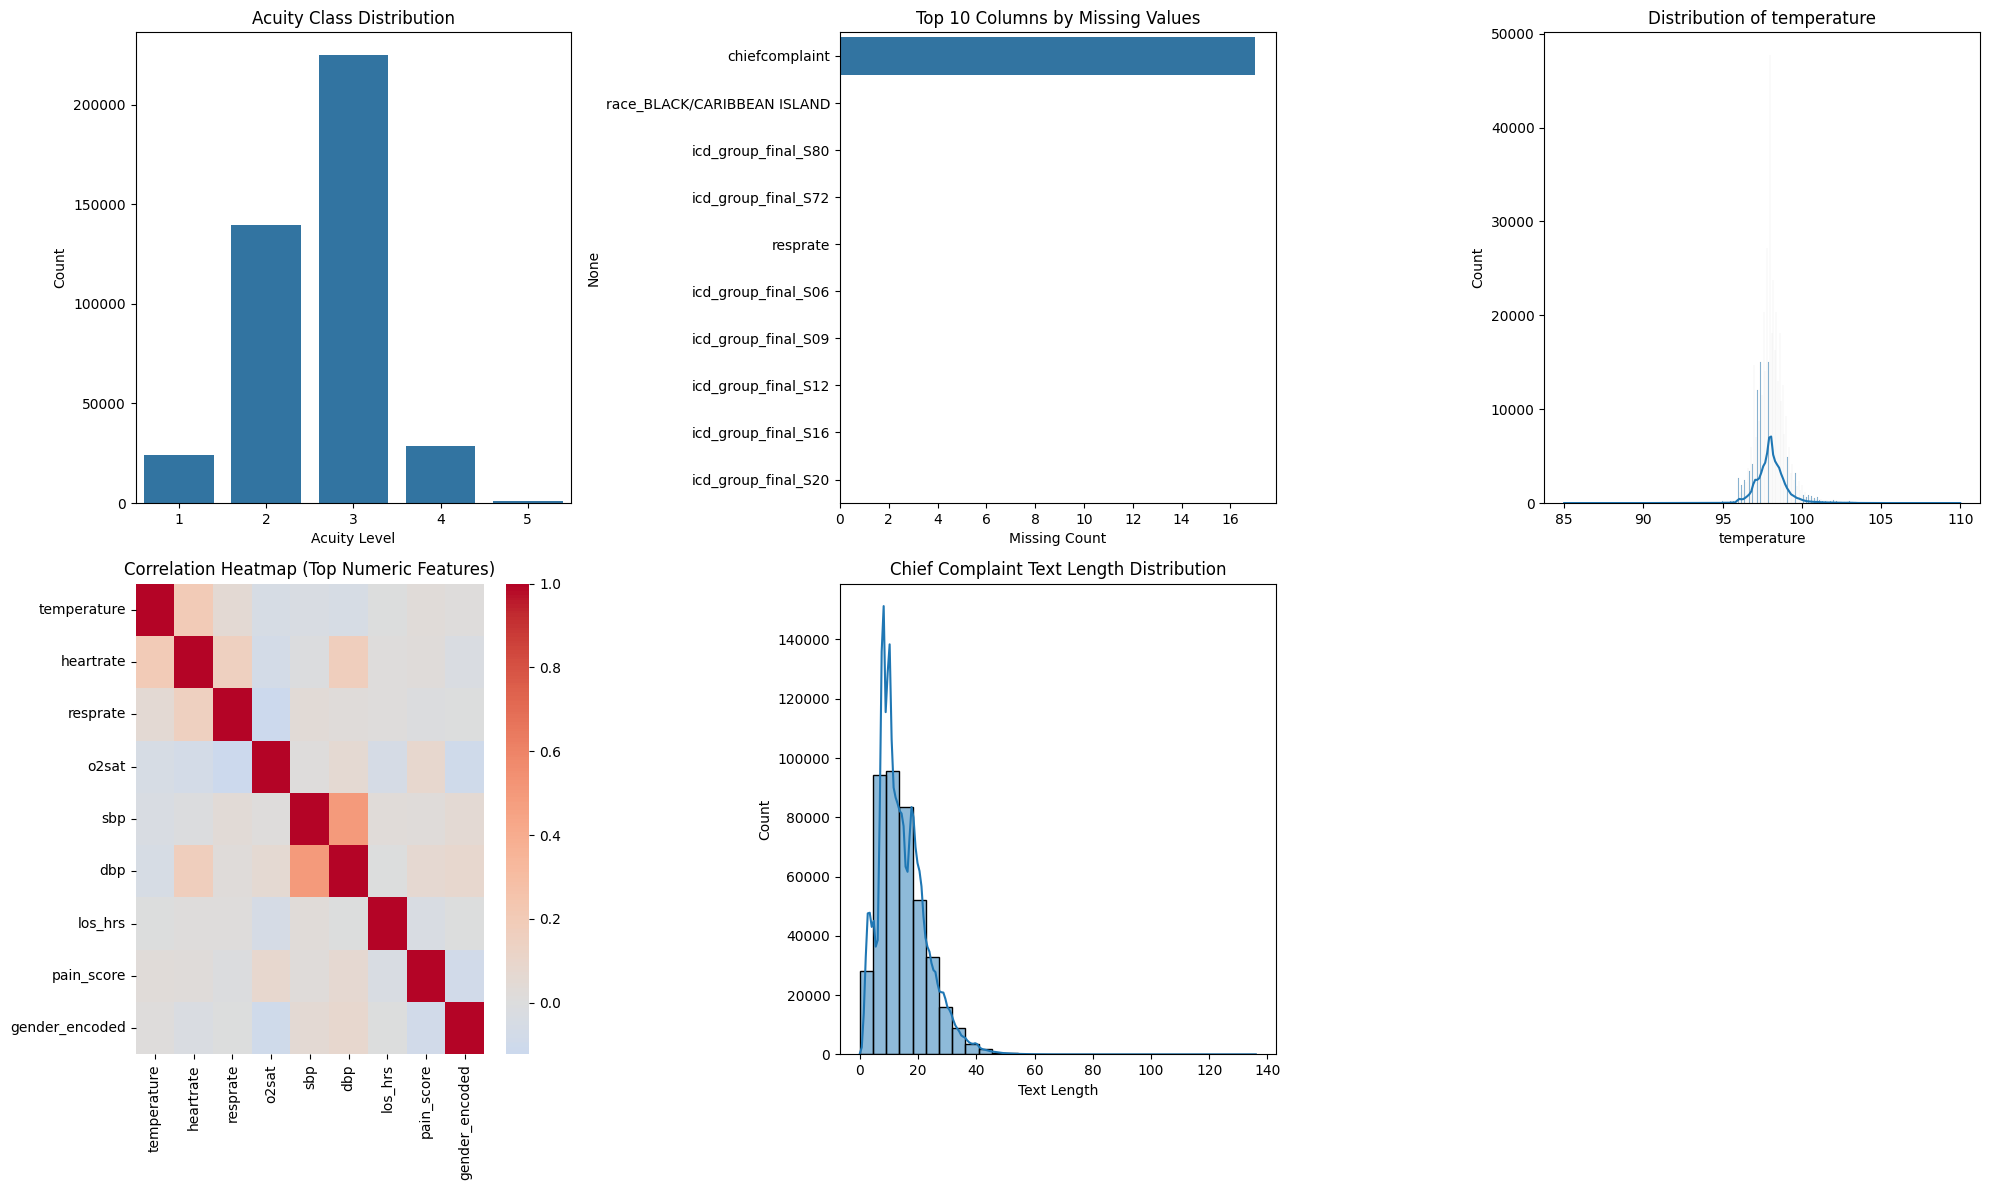

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed dataset
df = pd.read_csv("../data/processed_real_mimic_ed.csv")

# Recreate splits
y = df["acuity"]
X_text = df["chiefcomplaint"]
X_structured = df.drop(columns=["acuity", "chiefcomplaint"])

plt.figure(figsize=(20, 12))

# 1️⃣ Target Distribution
plt.subplot(2, 3, 1)
sns.countplot(x=y)
plt.title("Acuity Class Distribution")
plt.xlabel("Acuity Level")
plt.ylabel("Count")

# 2️⃣ Missing Values (Top 10)
plt.subplot(2, 3, 2)
missing = df.isnull().sum().sort_values(ascending=False).head(10)
sns.barplot(x=missing.values, y=missing.index)
plt.title("Top 10 Columns by Missing Values")
plt.xlabel("Missing Count")

# 3️⃣ Numeric Feature Distribution (first numeric column)
numeric_cols = X_structured.select_dtypes(include=np.number).columns
if len(numeric_cols) > 0:
    plt.subplot(2, 3, 3)
    sns.histplot(X_structured[numeric_cols[0]], kde=True)
    plt.title(f"Distribution of {numeric_cols[0]}")
    plt.xlabel(numeric_cols[0])

# 4️⃣ Correlation Heatmap (Top 15 numeric features)
if len(numeric_cols) >= 2:
    plt.subplot(2, 3, 4)
    top_numeric = numeric_cols[:15]
    corr = X_structured[top_numeric].corr()
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap (Top Numeric Features)")

# 5️⃣ Text Length Distribution
plt.subplot(2, 3, 5)

# Fill missing text safely
text_clean = X_text.fillna("").astype(str)

# Compute length
text_length = text_clean.str.len()

sns.histplot(text_length, bins=30, kde=True)
plt.title("Chief Complaint Text Length Distribution")
plt.xlabel("Text Length")

# 6️⃣ Unique Values Count (Top 10 categorical)
cat_cols = X_structured.select_dtypes(include="object").columns
if len(cat_cols) > 0:
    plt.subplot(2, 3, 6)
    unique_counts = X_structured[cat_cols].nunique().sort_values(ascending=False).head(10)
    sns.barplot(x=unique_counts.values, y=unique_counts.index)
    plt.title("Top 10 Categorical Features by Unique Values")
    plt.xlabel("Unique Count")

plt.tight_layout()
plt.show()

In [4]:
df["chiefcomplaint"].isnull().sum()

np.int64(17)